In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv(r"heart.csv")

Saving heart.csv to heart.csv


In [ ]:
X = data.drop("target", axis=1)
y = data["target"]


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train.values)
y_test = torch.FloatTensor(y_test.values)

In [ ]:
class HealthNN(nn.Module):
    def __init__(self, input_size):
        super(HealthNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def train_model(optimizer_name):
    model = HealthNN(X_train.shape[1])

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

    loss_fn = nn.BCELoss()

    # Training loop
    for epoch in range(50):
        model.train()

        y_pred = model(X_train).squeeze()
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).squeeze()
        predictions = (y_pred.numpy() > 0.5).astype(int)

    acc = accuracy_score(y_test.numpy(), predictions)

    return model, acc

In [ ]:
results = {}
for opt in ["SGD", "Adam", "RMSprop"]:
    model, acc = train_model(opt)
    results[opt] = acc
    print(f"{opt} Accuracy: {acc:.4f}")

SGD Accuracy: 0.5659
Adam Accuracy: 0.5317
RMSprop Accuracy: 0.7610


In [ ]:
model_sgd, acc_sgd = train_model("SGD")
model_adam, acc_adam = train_model("Adam")
model_rmsprop, acc_rmsprop = train_model("RMSprop")

print(f"Accuracy with SGD: {acc_sgd:.4f}")
print(f"Accuracy with Adam: {acc_adam:.4f}")
print(f"Accuracy with RMSprop: {acc_rmsprop:.4f}")

Accuracy with SGD: 0.4732
Accuracy with Adam: 0.7220
Accuracy with RMSprop: 0.8146


In [ ]:
best_optimizer = max(results, key=results.get)
print("\nBest Optimizer:", best_optimizer)

torch.save(model.state_dict(), "best_model.pth")


Best Optimizer: RMSprop


In [ ]:
model = HealthNN(X.shape[1])
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 🔷 Alert System
def health_alert(pred):
    if pred == 1:
        return "⚠️ High Risk - Immediate Check Required"
    else:
        return "✅ Normal Condition"

In [ ]:
def predict_patient(input_data):
    input_scaled = scaler.transform([input_data])
    input_tensor = torch.FloatTensor(input_scaled)

    with torch.no_grad():
        output = model(input_tensor)
        pred = int(output.item() > 0.5)

    return health_alert(pred)


In [ ]:
sample = [52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3] # Example with 13 features
print(predict_patient(sample))

⚠️ High Risk - Immediate Check Required


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
losses = []

model = HealthNN(X_train.shape[1])
model.load_state_dict(torch.load("best_model.pth"))

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

for epoch in range(50):
    model.train()

    y_pred = model(X_train).squeeze()
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

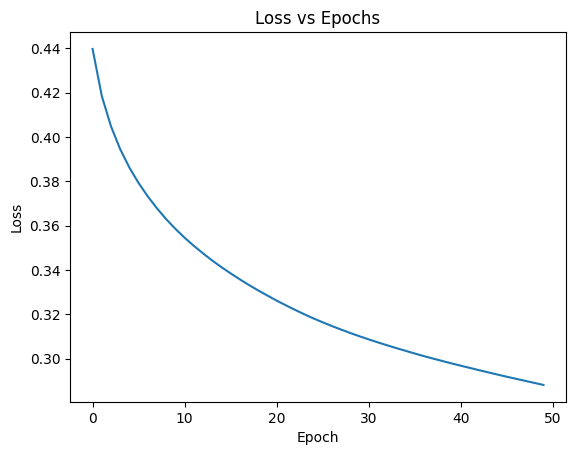

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the best model (RMSprop) on the test set
model_rmsprop.eval()
with torch.no_grad():
    y_pred_rmsprop = model_rmsprop(X_test).squeeze()
    predictions_rmsprop = (y_pred_rmsprop.numpy() > 0.5).astype(int)

cm = confusion_matrix(y_test.numpy(), predictions_rmsprop)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[77 25]
 [13 90]]
